In [1]:
# Kitap Satışlarında Dinamik Fiyatlama ve Kâr Optimizasyonu
# Python ile Veri Bilimi - Dönem Sonu Projesi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

C:\Users\hayru\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hayru\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
print("Notebook çalışıyor")

Notebook çalışıyor


In [3]:
df = pd.read_csv("samplesuperstore.csv")

print(df.shape)

df.head()

(10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [4]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           10194 non-null  float64
 1

In [6]:
# Tarih sütunlarını datetime formatına çevir

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.dtypes)

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code                  str
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object


In [7]:
# Teslim süresi (gün)

df["Teslim_Suresi"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date", "Ship Date", "Teslim_Suresi"]].head()

,Order Date,Ship Date,Teslim_Suresi
0,2023-01-03,2023-01-07,4
1,2023-01-04,2023-01-08,4
2,2023-01-04,2023-01-08,4
3,2023-01-04,2023-01-08,4
4,2023-01-05,2023-01-12,7


In [8]:
print(df["Order Date"].min())
print(df["Order Date"].max())

2023-01-03 00:00:00
2026-12-30 00:00:00


In [9]:
!pip install yfinance

In [10]:
import yfinance as yf

usdtry = yf.download(
    "TRY=X",
    start="2023-01-01",
    end="2027-01-01"
)

print(usdtry.shape)
usdtry.head()

[*********************100%***********************]  1 of 1 completed

(896, 5)


Price,Close,High,Low,Open,Volume
Ticker,TRY=X,TRY=X,TRY=X,TRY=X,TRY=X
Date,,,,,
2023-01-02,18.644730,18.731400,18.635990,18.644730,0
2023-01-03,18.743299,18.750500,18.687740,18.743299,0
2023-01-04,18.706869,18.768000,18.714840,18.706869,0
2023-01-05,18.735950,18.772261,18.726650,18.735950,0
2023-01-06,18.766600,18.787081,18.665501,18.766600,0


In [11]:
usdtry.columns

MultiIndex([( 'Close', 'TRY=X'),
            (  'High', 'TRY=X'),
            (   'Low', 'TRY=X'),
            (  'Open', 'TRY=X'),
            ('Volume', 'TRY=X')],
           names=['Price', 'Ticker'])

In [12]:
# Sadece kapanış kurunu al

usdtry = usdtry["Close"]

# Tarihi sütun yap

usdtry = usdtry.reset_index()

# Sütun adını değiştir

usdtry.columns = ["Date", "USDTRY"]

usdtry.head()


,Date,USDTRY
0,2023-01-02,18.644730
1,2023-01-03,18.743299
2,2023-01-04,18.706869
3,2023-01-05,18.735950
4,2023-01-06,18.766600


In [13]:
print(df["Order Date"].dtype)
print(usdtry["Date"].dtype)

datetime64[us]
datetime64[s]


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Veri setlerini tarih üzerinden birleştir

df_merged = pd.merge(
    df,
    usdtry,
    left_on="Order Date",
    right_on="Date",
    how="left"
)

print(df_merged.shape)

df_merged[["Order Date", "Sales", "Profit", "USDTRY"]].head()

(10194, 24)


,Order Date,Sales,Profit,USDTRY
0,2023-01-03,16.448,5.5512,18.743299
1,2023-01-04,3.540,-5.4870,18.706869
2,2023-01-04,11.784,4.2717,18.706869
3,2023-01-04,272.736,-64.7748,18.706869
4,2023-01-05,19.536,4.8840,18.735950


In [16]:
df_merged.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
Country/Region       0
City                 0
State/Province       0
Postal Code          0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Quantity             0
Discount             0
Profit               0
Teslim_Suresi        0
Date              3936
USDTRY            3936
dtype: int64

In [17]:
# Kur verilerini bir önceki günün değeriyle doldur

df_merged["USDTRY"] = df_merged["USDTRY"].ffill()

# Date sütununa artık ihtiyacımız yok

df_merged.drop("Date", axis=1, inplace=True)

# Tekrar kontrol

df_merged.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Teslim_Suresi     0
USDTRY            0
dtype: int64

In [18]:
df_merged[["Sales", "Quantity", "Discount", "Profit", "USDTRY"]].describe()

,Sales,Quantity,Discount,Profit,USDTRY
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417,37.652829
std,619.906839,2.228317,0.206249,232.465115,7.957403
min,0.444000,1.000000,0.000000,-6599.978000,18.706869
25%,17.220000,2.000000,0.000000,1.760800,32.382801
50%,53.910000,3.000000,0.200000,8.690000,39.720501
75%,209.500000,5.000000,0.200000,29.297925,45.430500
max,22638.480000,14.000000,0.800000,8399.976000,46.282902


In [19]:
# Kar marjı

df_merged["Kar_Marji"] = (
    df_merged["Profit"] / df_merged["Sales"]
)

df_merged[["Sales","Profit","Kar_Marji"]].head()

,Sales,Profit,Kar_Marji
0,16.448,5.5512,0.3375
1,3.540,-5.4870,-1.5500
2,11.784,4.2717,0.3625
3,272.736,-64.7748,-0.2375
4,19.536,4.8840,0.2500


In [20]:
df_merged["Siparis_Ayi"] = df_merged["Order Date"].dt.month

df_merged[["Order Date","Siparis_Ayi"]].head()

,Order Date,Siparis_Ayi
0,2023-01-03,1
1,2023-01-04,1
2,2023-01-04,1
3,2023-01-04,1
4,2023-01-05,1


In [21]:
df_merged["Kur_Etkisi"] = (
    df_merged["Sales"] * df_merged["USDTRY"]
)

df_merged[["Sales","USDTRY","Kur_Etkisi"]].head()

,Sales,USDTRY,Kur_Etkisi
0,16.448,18.743299,308.289790
1,3.540,18.706869,66.222317
2,11.784,18.706869,220.441746
3,272.736,18.706869,5102.036658
4,19.536,18.735950,366.025528


In [22]:
df_merged.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64

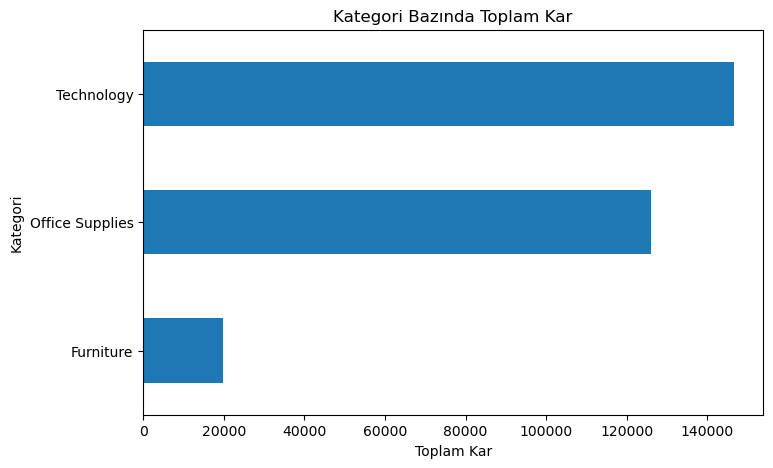

In [23]:
df_merged.groupby("Category")["Profit"].sum().sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Kategori Bazında Toplam Kar")
plt.xlabel("Toplam Kar")
plt.ylabel("Kategori")

plt.show()

In [24]:
df_merged[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.218882
Profit,-0.218882,1.000000


In [25]:
df_merged[["Sales","Quantity","Discount","Profit","USDTRY"]].corr()

,Sales,Quantity,Discount,Profit,USDTRY
Sales,1.000000,0.198457,-0.027756,0.481460,-0.009360
Quantity,0.198457,1.000000,0.007475,0.066145,-0.001551
Discount,-0.027756,0.007475,1.000000,-0.218882,0.002332
Profit,0.481460,0.066145,-0.218882,1.000000,0.006648
USDTRY,-0.009360,-0.001551,0.002332,0.006648,1.000000


In [26]:
df_merged.groupby("Category")[["Sales","Profit"]].mean()

,Sales,Profit
Category,,
Furniture,342.911295,8.964105
Office Supplies,119.434288,20.565183
Technology,450.344922,78.575537


In [27]:
df_model = df_merged.copy()

print(df_model.shape)

(10194, 26)


In [28]:
df_model.select_dtypes(include="object").columns

C:\Users\hayru\AppData\Local\Temp\ipykernel_26880\3775104594.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.select_dtypes(include="object").columns


Index(['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment',
       'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='str')

In [29]:
drop_cols = [
    "Row ID",
    "Order ID",
    "Customer ID",
    "Customer Name",
    "Product ID",
    "Product Name",
    "Country/Region",
    "Postal Code"
]

df_model = df_model.drop(columns=drop_cols)

print(df_model.shape)

(10194, 18)


In [30]:
y = df_model["Profit"]

X = df_model.drop(columns=["Profit"])

print(X.shape)
print(y.shape)

(10194, 17)
(10194,)


In [31]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
X.head()

(10194, 635)


,Order Date,Ship Date,Sales,Quantity,Discount,Teslim_Suresi,USDTRY,Kar_Marji,Siparis_Ayi,Kur_Etkisi,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,2023-01-03,2023-01-07,16.448,2,0.2,4,18.743299,0.3375,1,308.289790,...,False,False,False,False,False,True,False,False,False,False
1,2023-01-04,2023-01-08,3.540,2,0.8,4,18.706869,-1.5500,1,66.222317,...,False,False,False,False,False,False,False,False,False,False
2,2023-01-04,2023-01-08,11.784,3,0.2,4,18.706869,0.3625,1,220.441746,...,False,False,False,True,False,False,False,False,False,False
3,2023-01-04,2023-01-08,272.736,3,0.2,4,18.706869,-0.2375,1,5102.036658,...,False,False,False,False,False,False,False,True,False,False
4,2023-01-05,2023-01-12,19.536,3,0.2,7,18.735950,0.2500,1,366.025528,...,False,False,False,False,False,False,False,False,False,False


In [32]:
X = X.drop(columns=["Kar_Marji"])

In [33]:
X["Order_Year"] = X["Order Date"].dt.year
X["Order_Month"] = X["Order Date"].dt.month

X["Ship_Year"] = X["Ship Date"].dt.year
X["Ship_Month"] = X["Ship Date"].dt.month

X = X.drop(columns=["Order Date", "Ship Date"])

In [34]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(10194, 636)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8155, 636)
(2039, 636)


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 23.92135357001799
RMSE: 160.4709872110351
R2  : 0.7130043988482462


In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Sales,0.429269
2,Discount,0.234553
6,Kur_Etkisi,0.155470
4,USDTRY,0.022847
1,Quantity,0.015770
618,Sub-Category_Binders,0.013570
630,Sub-Category_Supplies,0.008993
3,Teslim_Suresi,0.008514
633,Order_Month,0.007721
621,Sub-Category_Copiers,0.007212


In [39]:
sim_df = df_merged.copy()

print("Finansal simülasyon verisi hazır")

Finansal simülasyon verisi hazır


In [40]:
mevcut_kar = sim_df["Profit"].sum()

print("Mevcut Toplam Kar:", mevcut_kar)

Mevcut Toplam Kar: 292296.8146


In [41]:
sim_df["Yeni_Discount"] = sim_df["Discount"] * 0.90

sim_df["Tahmini_Yeni_Kar"] = (
    sim_df["Profit"] +
    (sim_df["Discount"] - sim_df["Yeni_Discount"]) * sim_df["Sales"]
)

yeni_kar = sim_df["Tahmini_Yeni_Kar"].sum()

print("Mevcut Kar :", round(mevcut_kar, 2))
print("Yeni Kar   :", round(yeni_kar, 2))
print("Kar Artışı :", round(yeni_kar - mevcut_kar, 2))

Mevcut Kar : 292296.81
Yeni Kar   : 324830.32
Kar Artışı : 32533.5


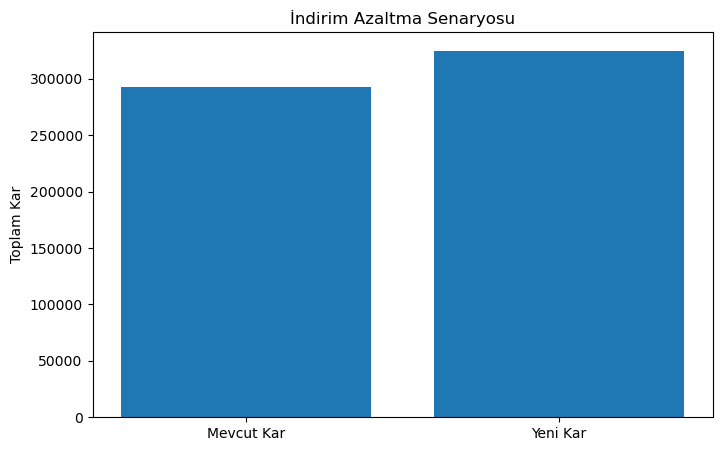

In [42]:
import matplotlib.pyplot as plt

durumlar = ["Mevcut Kar", "Yeni Kar"]
degerler = [mevcut_kar, yeni_kar]

plt.figure(figsize=(8,5))
plt.bar(durumlar, degerler)

plt.title("İndirim Azaltma Senaryosu")
plt.ylabel("Toplam Kar")

plt.show()

In [43]:
teknoloji = sim_df[sim_df["Category"] == "Technology"].copy()

mevcut_teknoloji_kar = teknoloji["Profit"].sum()

teknoloji["Yeni_USDTRY"] = teknoloji["USDTRY"] * 1.15

teknoloji["Tahmini_Kar"] = (
    teknoloji["Profit"] +
    (teknoloji["Yeni_USDTRY"] - teknoloji["USDTRY"]) * 5
)

yeni_teknoloji_kar = teknoloji["Tahmini_Kar"].sum()

print("Mevcut Teknoloji Karı :", round(mevcut_teknoloji_kar,2))
print("Yeni Teknoloji Karı   :", round(yeni_teknoloji_kar,2))
print("Kar Farkı             :", round(yeni_teknoloji_kar - mevcut_teknoloji_kar,2))

Mevcut Teknoloji Karı : 146543.38
Yeni Teknoloji Karı   : 199300.01
Kar Farkı             : 52756.64


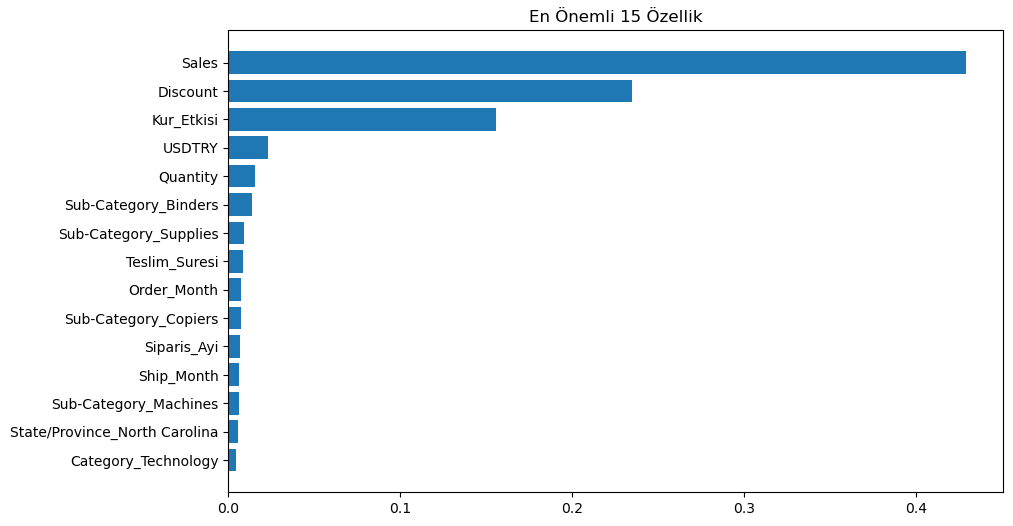

In [44]:
top15 = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.title("En Önemli 15 Özellik")
plt.gca().invert_yaxis()

plt.show()

In [45]:

usdtry.to_csv(
    "usdtry_verisi.csv",
    index=False
)

print("Kaydedildi")


Kaydedildi
